In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
test_df = pd.read_csv('/content/drive/My Drive/Data/Capstone/test.csv')
train_df = pd.read_csv('/content/drive/My Drive/Data/Capstone/train.csv')
bts_df = pd.read_csv('/content/drive/My Drive/Data/Capstone/bts_data.csv')

In [4]:
print(test_df.dtypes)

Date                    object
Region                  object
Brand                   object
Model                   object
Vehicle_Type            object
Battery_Capacity_kWh     int64
Discount_Percentage      int64
Customer_Segment        object
Fast_Charging_Option    object
dtype: object


In [5]:
test_df['Date'] = pd.to_datetime(test_df['Date'], format = "%Y-%m")
print(test_df.dtypes)

Date                    datetime64[ns]
Region                          object
Brand                           object
Model                           object
Vehicle_Type                    object
Battery_Capacity_kWh             int64
Discount_Percentage              int64
Customer_Segment                object
Fast_Charging_Option            object
dtype: object


In [6]:
print(train_df.dtypes)

Date                    object
Region                  object
Brand                   object
Model                   object
Vehicle_Type            object
Battery_Capacity_kWh     int64
Discount_Percentage      int64
Customer_Segment        object
Fast_Charging_Option    object
Units_Sold               int64
Revenue                  int64
dtype: object


In [7]:
train_df['Date'] = pd.to_datetime(train_df['Date'], format = "%Y-%m")
print(train_df.dtypes)

Date                    datetime64[ns]
Region                          object
Brand                           object
Model                           object
Vehicle_Type                    object
Battery_Capacity_kWh             int64
Discount_Percentage              int64
Customer_Segment                object
Fast_Charging_Option            object
Units_Sold                       int64
Revenue                          int64
dtype: object


In [8]:
bts_df.head()

,Year,Hybrid Electric,Plug-in Hybrid Electric,Electric
0,2010,274684,326,19
1,2011,268749,7671,10092
2,2012,434648,38584,14587
3,2013,495535,49008,48094
4,2014,452172,55357,63525


In [9]:
print(bts_df.dtypes)

Year                       int64
Hybrid Electric            int64
Plug-in Hybrid Electric    int64
Electric                   int64
dtype: object


# **Years and Quarters**

In [10]:
train_df['Year'] = train_df['Date'].dt.year
train_df['Quarter'] = train_df['Date'].dt.quarter

In [11]:
train_df.head()

,Date,Region,Brand,Model,Vehicle_Type,Battery_Capacity_kWh,Discount_Percentage,Customer_Segment,Fast_Charging_Option,Units_Sold,Revenue,Year,Quarter
0,2023-07-01,Oceania,Toyota,i4,Crossover,62,6,High Income,No,260,3699780,2023,3
1,2023-03-01,Oceania,Toyota,Leaf,Truck,70,19,High Income,Yes,347,7801424,2023,1
2,2023-05-01,North America,Toyota,ID.5,Crossover,81,13,Middle Income,No,294,4813013,2023,2
3,2023-02-01,Oceania,Tesla,Corolla EV,Truck,73,4,High Income,Yes,281,7484912,2023,1
4,2023-10-01,North America,BYD,Leaf,Coupe,52,4,High Income,No,166,4025360,2023,4


# **Total Sales and Market Share**

In [12]:
bts_df['Total_sales'] = bts_df['Hybrid Electric'] + bts_df['Plug-in Hybrid Electric'] + bts_df['Electric']
bts_df['Electric_share'] = bts_df['Electric'] / bts_df['Total_sales']
bts_df['Plug-in_Hybrid_share'] = bts_df['Plug-in Hybrid Electric'] / bts_df['Total_sales']
bts_df['Hybrid_share'] = bts_df['Hybrid Electric'] / bts_df['Total_sales']

In [13]:
bts_df.head()

,Year,Hybrid Electric,Plug-in Hybrid Electric,Electric,Total_sales,Electric_share,Plug-in_Hybrid_share,Hybrid_share
0,2010,274684,326,19,275029,0.000069,0.001185,0.998746
1,2011,268749,7671,10092,286512,0.035224,0.026774,0.938003
2,2012,434648,38584,14587,487819,0.029902,0.079095,0.891003
3,2013,495535,49008,48094,592637,0.081153,0.082695,0.836153
4,2014,452172,55357,63525,571054,0.111242,0.096938,0.791820


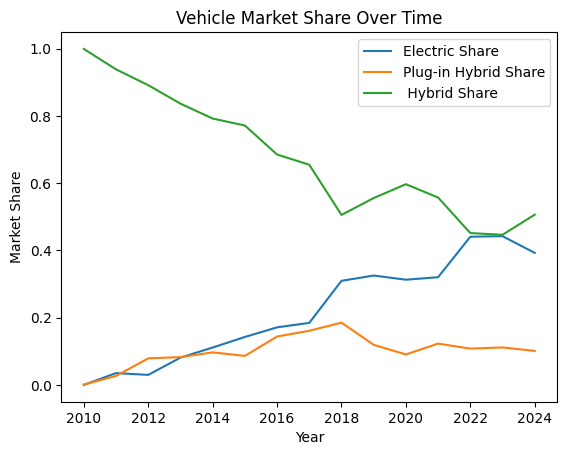

In [14]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(bts_df['Year'], bts_df['Electric_share'], label='Electric Share')
plt.plot(bts_df['Year'], bts_df['Plug-in_Hybrid_share'], label='Plug-in Hybrid Share')
plt.plot(bts_df['Year'], bts_df['Hybrid_share'], label=' Hybrid Share')

plt.xlabel("Year")
plt.ylabel("Market Share")
plt.title("Vehicle Market Share Over Time")
plt.legend()

plt.show()

# **Regional Breakdown**

In [15]:
print(train_df.columns)

Index(['Date', 'Region', 'Brand', 'Model', 'Vehicle_Type',
       'Battery_Capacity_kWh', 'Discount_Percentage', 'Customer_Segment',
       'Fast_Charging_Option', 'Units_Sold', 'Revenue', 'Year', 'Quarter'],
      dtype='object')


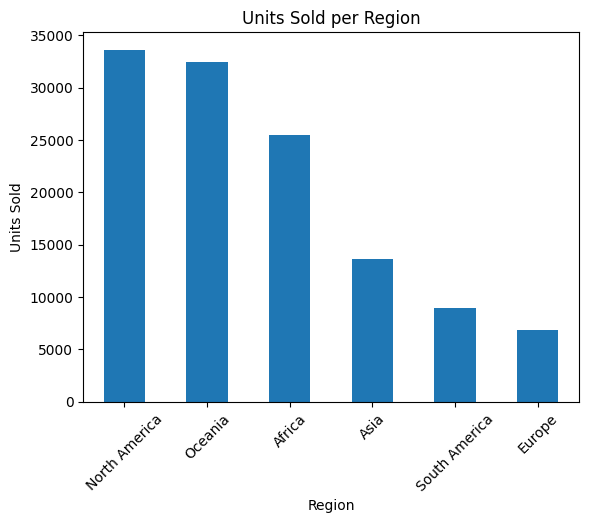

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

region_sales = train_df.groupby("Region")["Units_Sold"].sum()

region_sales = region_sales.sort_values(ascending=False)

plt.figure()
region_sales.plot(kind="bar")

plt.title("Units Sold per Region")
plt.xlabel("Region")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)
plt.show()

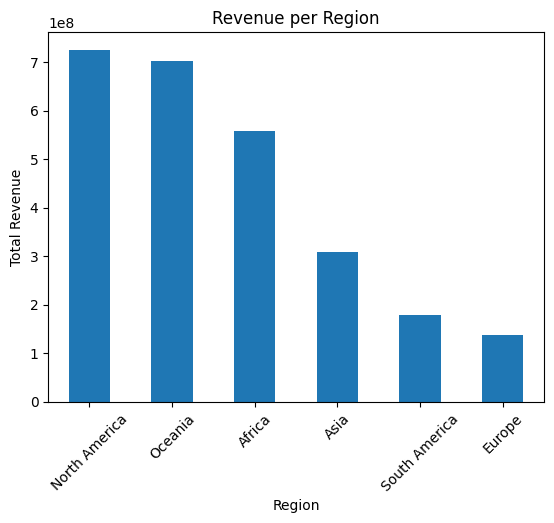

In [17]:
region_revenue = train_df.groupby("Region")["Revenue"].sum()

region_revenue = region_revenue.sort_values(ascending=False)

plt.figure()
region_revenue.plot(kind="bar")

plt.title("Revenue per Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.show()

In [18]:
region_df = train_df.groupby('Region').agg({
    'Units_Sold': 'sum',
    'Revenue': 'sum'
}).reset_index()

region_df.head()

,Region,Units_Sold,Revenue
0,Africa,25488,558678316
1,Asia,13642,308697805
2,Europe,6817,137626721
3,North America,33636,725573762
4,Oceania,32457,702983779


# **Results**

Growth Feature

Result: Year-over-year growth rates were calculated

Findings:
- EV demand is accelerating
- EV adoption is not constant but rapidly increasing over time


Demand Insight

- Highest demand with the highest units sold and revenue is in North America. This is where I will make predictions
- Growth is not linear but is rapidly increasing
- Indicates strong long-term market expansion